# Required Libraries + Load in Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
# Read KNMI weather file
weather = pd.read_csv("Weather 2019-2025/homogenoues weather data.txt", sep=",", skiprows=51, header=0)

# Parse date column once so later filtering works reliably
weather["YYYYMMDD"] = pd.to_datetime(weather["YYYYMMDD"], format="%Y%m%d", errors="coerce")

# Keep only rows from 2019-01-01 through 2025-12-31 (inclusive)
start_date = pd.Timestamp("2019-01-01")
end_date = pd.Timestamp("2025-12-31")
weather = weather[(weather["YYYYMMDD"] >= start_date) & (weather["YYYYMMDD"] <= end_date)].copy()

C:\Users\johan\AppData\Local\Temp\ipykernel_3836\3977227864.py:2: DtypeWarning: Columns (0: DDVEC, 1: FHVEC, 2:    FG, 3:   FHX, 4:  FHXH, 5:   FHN, 6:  FHNH, 7:   TNH, 8:   TXH, 9:  T10N, 10:    SQ, 11:    SP, 12:     Q, 13:    DR, 14:    RH, 15:   RHX, 16:    PG, 17:    PX, 18:    PN, 19:   VVN, 20:    UG, 21:    UX, 22:   UXH, 23:    UN, 24:   UNH, 25:  EV24) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv("Weather 2019-2025/homogenoues weather data.txt", sep=",", skiprows=51, header=0)


In [3]:
# Normalize KNMI headers, so that mapping keys match
weather.columns = weather.columns.str.strip().str.lstrip("#").str.strip()

# Map original column names to more descriptive labels
column_map = {
    'STN': 'Station',
    'YYYYMMDD': 'Date',
    'DDVEC': 'Wind direction vector mean',  # degrees: 0=N, 90=E, 180=S, 270=W
    'FHVEC': 'Windspeed vector mean',
    'FG': 'Daily mean windspeed',
    'FHX': 'Max hourly mean windspeed',
    'FHXH': 'Hour of max hourly mean windspeed',
    'FHN': 'Min hourly mean windspeed',
    'FHNH': 'Hour of min hourly mean windspeed',
    'FXX': 'Max wind gust',
    'FXXH': 'Hour of max wind gust',
    'TG': 'Daily mean temperature',  # 0.1 degrees Celsius
    'TN': 'Min temperature',  # 0.1 degrees Celsius
    'TNH': 'Hour TN measured',
    'TX': 'Max temperature',  # 0.1 degrees Celsius
    'TXH': 'Hour TX measured',
    'T10N': 'Min temperature 10cm above surface',  # 0.1 degrees Celsius
    'T10NH': '6-hour period T10N measured',
    'SQ': 'Sunshine duration',  # 0.1 hour
    'SP': 'Percent max potential sunshine duration',
    'Q': 'Global radiation',  # J/cm2
    'DR': 'Precipitation duration',  # 0.1 hour
    'RH': 'Daily precipitation amount',  # 0.1 mm
    'RHX': 'Max hourly precipitation amount',  # 0.1 mm
    'RHXH': 'Hour RHX measured',
    'PG': 'Daily mean sea level pressure',  # 0.1 hPa
    'PX': 'Max hourly sea level pressure',  # 0.1 hPa
    'PXH': 'Hour PX measured',
    'PN': 'Min hourly sea level pressure',  # 0.1 hPa
    'PNH': 'Hour PN measured',
    'VVN': 'Min visibility',  # 0.1 km
    'VVNH': 'Hour VVN measured',
    'VVX': 'Max visibility',  # 0.1 km
    'VVXH': 'Hour VVX measured',
    'NG': 'Mean daily cloud cover',  # octas
    'UG': 'Daily mean relative humidity',  # percent
    'UX': 'Max relative humidity',  # percent
    'UXH': 'Hour UX measured',
    'UN': 'Min relative humidity',  # percent
    'UNH': 'Hour UN measured',
    'EV24': 'Potential evapotranspiration (Makkink)'  # 0.1 mm
}

weather = weather.rename(columns=column_map)

# Convert all columns except Date to numeric (spaces become NaN)
num_cols = [c for c in weather.columns if c != 'Date']
weather[num_cols] = weather[num_cols].apply(pd.to_numeric, errors='coerce')

# Analyzing the Data

In [4]:
# Display basic information about the DataFrame: 
# number of rows, columns, data types, and non-null counts

weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 2557 entries, 43099 to 45655
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Station                                  2557 non-null   int64         
 1   Date                                     2557 non-null   datetime64[us]
 2   Wind direction vector mean               2557 non-null   int64         
 3   Windspeed vector mean                    2557 non-null   int64         
 4   Daily mean windspeed                     2557 non-null   int64         
 5   Max hourly mean windspeed                2557 non-null   int64         
 6   Hour of max hourly mean windspeed        2557 non-null   int64         
 7   Min hourly mean windspeed                2557 non-null   int64         
 8   Hour of min hourly mean windspeed        2557 non-null   int64         
 9   Max wind gust                            2557 n

In [5]:
weather.describe()

,Station,Date,Wind direction vector mean,Windspeed vector mean,Daily mean windspeed,Max hourly mean windspeed,Hour of max hourly mean windspeed,Min hourly mean windspeed,Hour of min hourly mean windspeed,Max wind gust,...,Hour VVN measured,Max visibility,Hour VVX measured,Mean daily cloud cover,Daily mean relative humidity,Max relative humidity,Hour UX measured,Min relative humidity,Hour UN measured,Potential evapotranspiration (Makkink)
count,2557.0,2557,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,...,2557.000000,2557.000000,2557.000000,2554.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,260.0,2022-07-02 00:00:00,190.808369,29.271412,33.369183,51.286664,10.910442,16.104810,8.427063,102.655456,...,9.897927,78.020727,12.098944,6.060689,79.021118,94.676965,9.556903,61.203363,13.448573,17.732499
min,260.0,2019-01-01 00:00:00,1.000000,0.000000,7.000000,20.000000,1.000000,0.000000,1.000000,30.000000,...,1.000000,15.000000,1.000000,0.000000,37.000000,52.000000,1.000000,16.000000,1.000000,0.000000
25%,260.0,2020-10-01 00:00:00,131.000000,18.000000,23.000000,40.000000,8.000000,10.000000,1.000000,80.000000,...,3.000000,75.000000,10.000000,5.000000,73.000000,93.000000,2.000000,49.000000,12.000000,5.000000
50%,260.0,2022-07-02 00:00:00,206.000000,27.000000,31.000000,50.000000,11.000000,10.000000,4.000000,100.000000,...,6.000000,81.000000,13.000000,7.000000,80.000000,97.000000,5.000000,61.000000,14.000000,14.000000
75%,260.0,2024-04-01 00:00:00,250.000000,38.000000,41.000000,60.000000,14.000000,20.000000,18.000000,120.000000,...,19.000000,83.000000,16.000000,8.000000,87.000000,98.000000,20.000000,74.000000,15.000000,28.000000
max,260.0,2025-12-31 00:00:00,360.000000,94.000000,98.000000,150.000000,24.000000,70.000000,24.000000,310.000000,...,24.000000,83.000000,24.000000,8.000000,100.000000,100.000000,24.000000,98.000000,24.000000,59.000000
std,0.0,NaN,90.926323,14.995639,13.845270,18.055588,5.397954,11.798449,8.547612,37.214587,...,8.519387,7.072227,5.741769,2.163471,10.765404,5.835016,8.899565,16.182888,4.024110,14.754101


# Dealing with Missing Values

In [6]:
total = weather.isnull().sum().sort_values(ascending=False)
percent = (weather.isnull().sum()/weather.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
Mean daily cloud cover,3,0.001173
Date,0,0.000000
Wind direction vector mean,0,0.000000
Windspeed vector mean,0,0.000000
Daily mean windspeed,0,0.000000
Max hourly mean windspeed,0,0.000000
Hour of max hourly mean windspeed,0,0.000000
Min hourly mean windspeed,0,0.000000
Station,0,0.000000
Hour of min hourly mean windspeed,0,0.000000


In [7]:
# Show the rows where Mean daily cloud cover is missing
weather[weather['Mean daily cloud cover'].isna()]

,Station,Date,Wind direction vector mean,Windspeed vector mean,Daily mean windspeed,Max hourly mean windspeed,Hour of max hourly mean windspeed,Min hourly mean windspeed,Hour of min hourly mean windspeed,Max wind gust,...,Hour VVN measured,Max visibility,Hour VVX measured,Mean daily cloud cover,Daily mean relative humidity,Max relative humidity,Hour UX measured,Min relative humidity,Hour UN measured,Potential evapotranspiration (Makkink)
45546,260,2025-09-13,189,39,40,60,10,20,15,110,...,15,83,1,NaN,85,95,24,59,12,15
45547,260,2025-09-14,191,32,37,50,12,20,4,100,...,5,83,16,NaN,82,98,4,52,14,24
45548,260,2025-09-15,226,78,79,100,10,40,1,210,...,11,73,14,NaN,73,95,1,52,14,24


In [8]:
# Replace NaN in Mean daily cloud cover with None
weather['Mean daily cloud cover'] = weather['Mean daily cloud cover'].fillna(None)

In [15]:
weather.isna()

,Station,Date,Wind direction vector mean,Windspeed vector mean,Daily mean windspeed,Max hourly mean windspeed,Hour of max hourly mean windspeed,Min hourly mean windspeed,Hour of min hourly mean windspeed,Max wind gust,...,Hour VVN measured,Max visibility,Hour VVX measured,Mean daily cloud cover,Daily mean relative humidity,Max relative humidity,Hour UX measured,Min relative humidity,Hour UN measured,Potential evapotranspiration (Makkink)
43099,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43100,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43101,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43102,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43103,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45651,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45652,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45653,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45654,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
# Check for duplicates
weather.duplicated().sum()

np.int64(0)

# Univariate & Bivariate Analysis

## Univariate

In [17]:
weather.describe()

,Station,Date,Wind direction vector mean,Windspeed vector mean,Daily mean windspeed,Max hourly mean windspeed,Hour of max hourly mean windspeed,Min hourly mean windspeed,Hour of min hourly mean windspeed,Max wind gust,...,Hour VVN measured,Max visibility,Hour VVX measured,Mean daily cloud cover,Daily mean relative humidity,Max relative humidity,Hour UX measured,Min relative humidity,Hour UN measured,Potential evapotranspiration (Makkink)
count,2557.0,2557,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,...,2557.000000,2557.000000,2557.000000,2554.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,260.0,2022-07-02 00:00:00,190.808369,29.271412,33.369183,51.286664,10.910442,16.104810,8.427063,102.655456,...,9.897927,78.020727,12.098944,6.060689,79.021118,94.676965,9.556903,61.203363,13.448573,17.732499
min,260.0,2019-01-01 00:00:00,1.000000,0.000000,7.000000,20.000000,1.000000,0.000000,1.000000,30.000000,...,1.000000,15.000000,1.000000,0.000000,37.000000,52.000000,1.000000,16.000000,1.000000,0.000000
25%,260.0,2020-10-01 00:00:00,131.000000,18.000000,23.000000,40.000000,8.000000,10.000000,1.000000,80.000000,...,3.000000,75.000000,10.000000,5.000000,73.000000,93.000000,2.000000,49.000000,12.000000,5.000000
50%,260.0,2022-07-02 00:00:00,206.000000,27.000000,31.000000,50.000000,11.000000,10.000000,4.000000,100.000000,...,6.000000,81.000000,13.000000,7.000000,80.000000,97.000000,5.000000,61.000000,14.000000,14.000000
75%,260.0,2024-04-01 00:00:00,250.000000,38.000000,41.000000,60.000000,14.000000,20.000000,18.000000,120.000000,...,19.000000,83.000000,16.000000,8.000000,87.000000,98.000000,20.000000,74.000000,15.000000,28.000000
max,260.0,2025-12-31 00:00:00,360.000000,94.000000,98.000000,150.000000,24.000000,70.000000,24.000000,310.000000,...,24.000000,83.000000,24.000000,8.000000,100.000000,100.000000,24.000000,98.000000,24.000000,59.000000
std,0.0,NaN,90.926323,14.995639,13.845270,18.055588,5.397954,11.798449,8.547612,37.214587,...,8.519387,7.072227,5.741769,2.163471,10.765404,5.835016,8.899565,16.182888,4.024110,14.754101


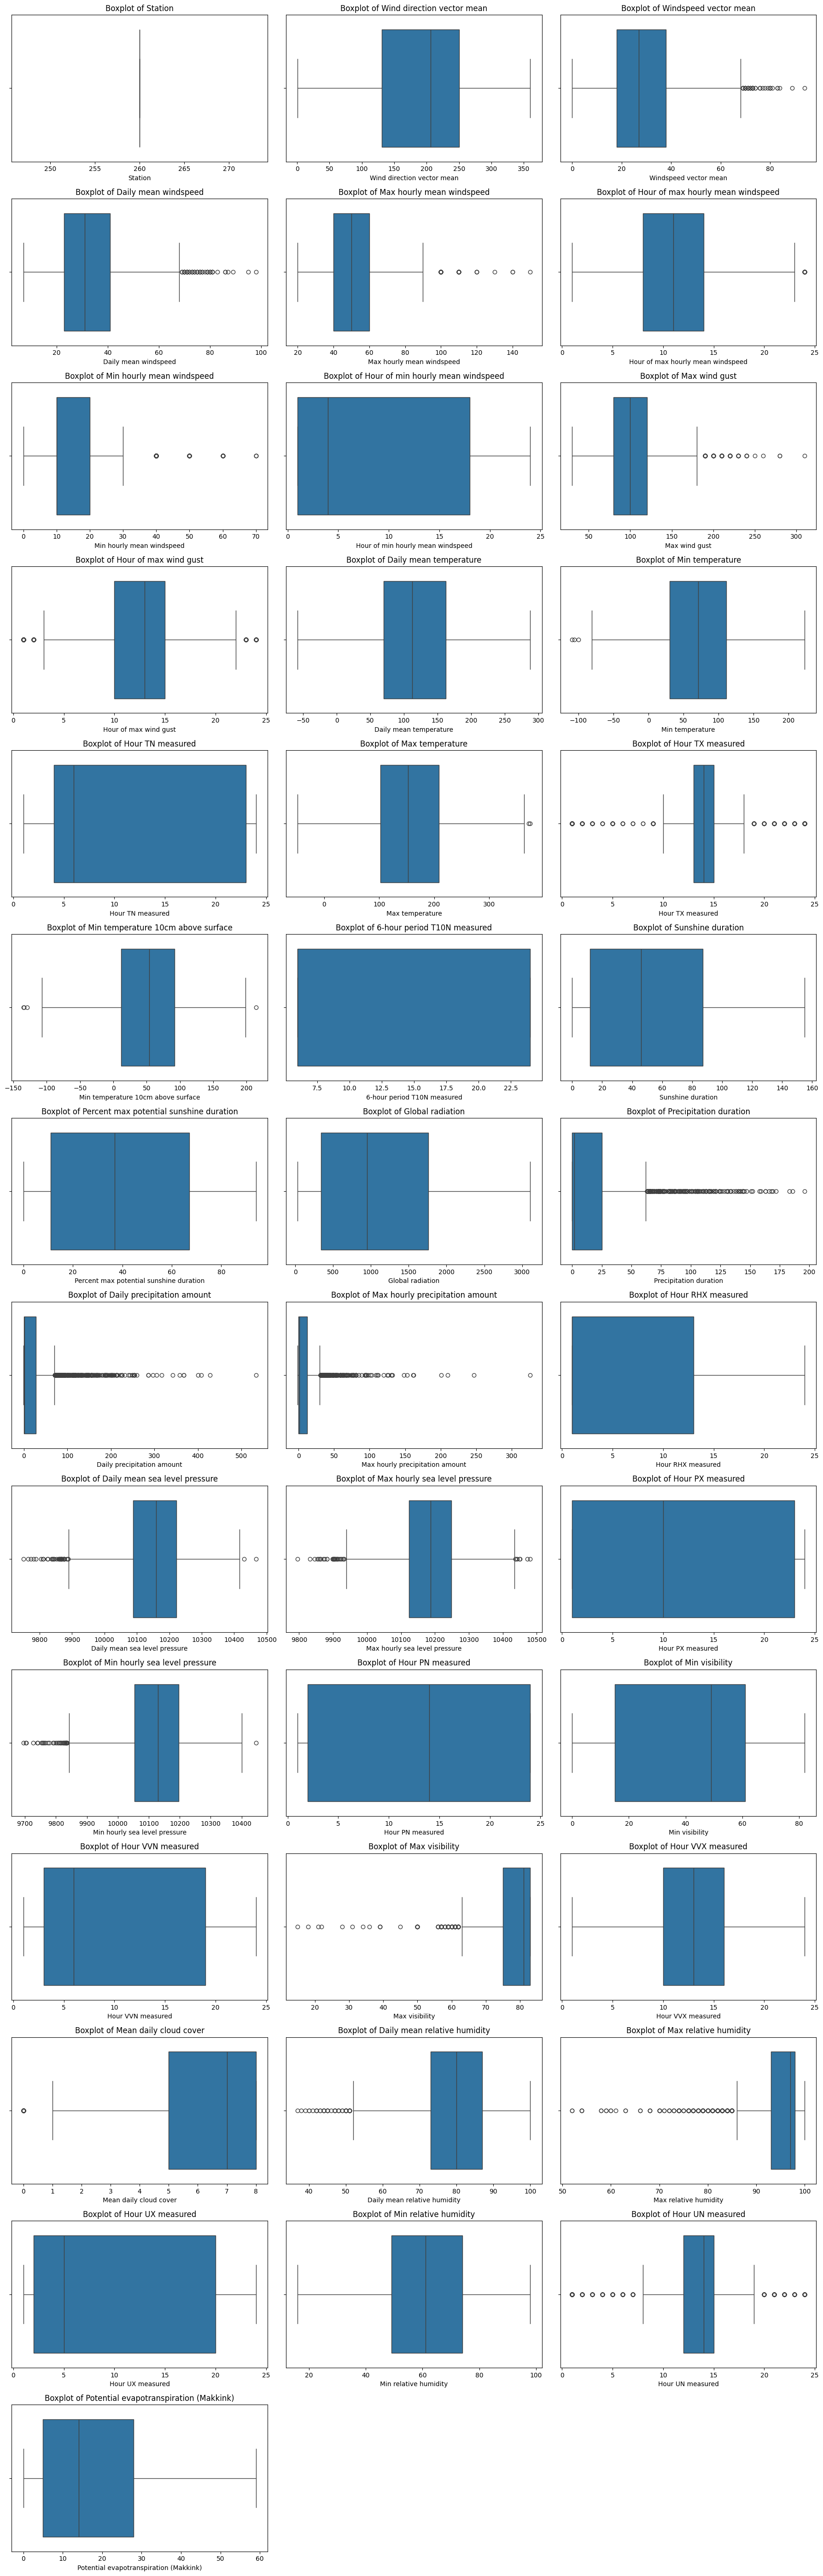

In [10]:
#boxplot: for outliers and data spread
num_cols = weather.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=weather[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

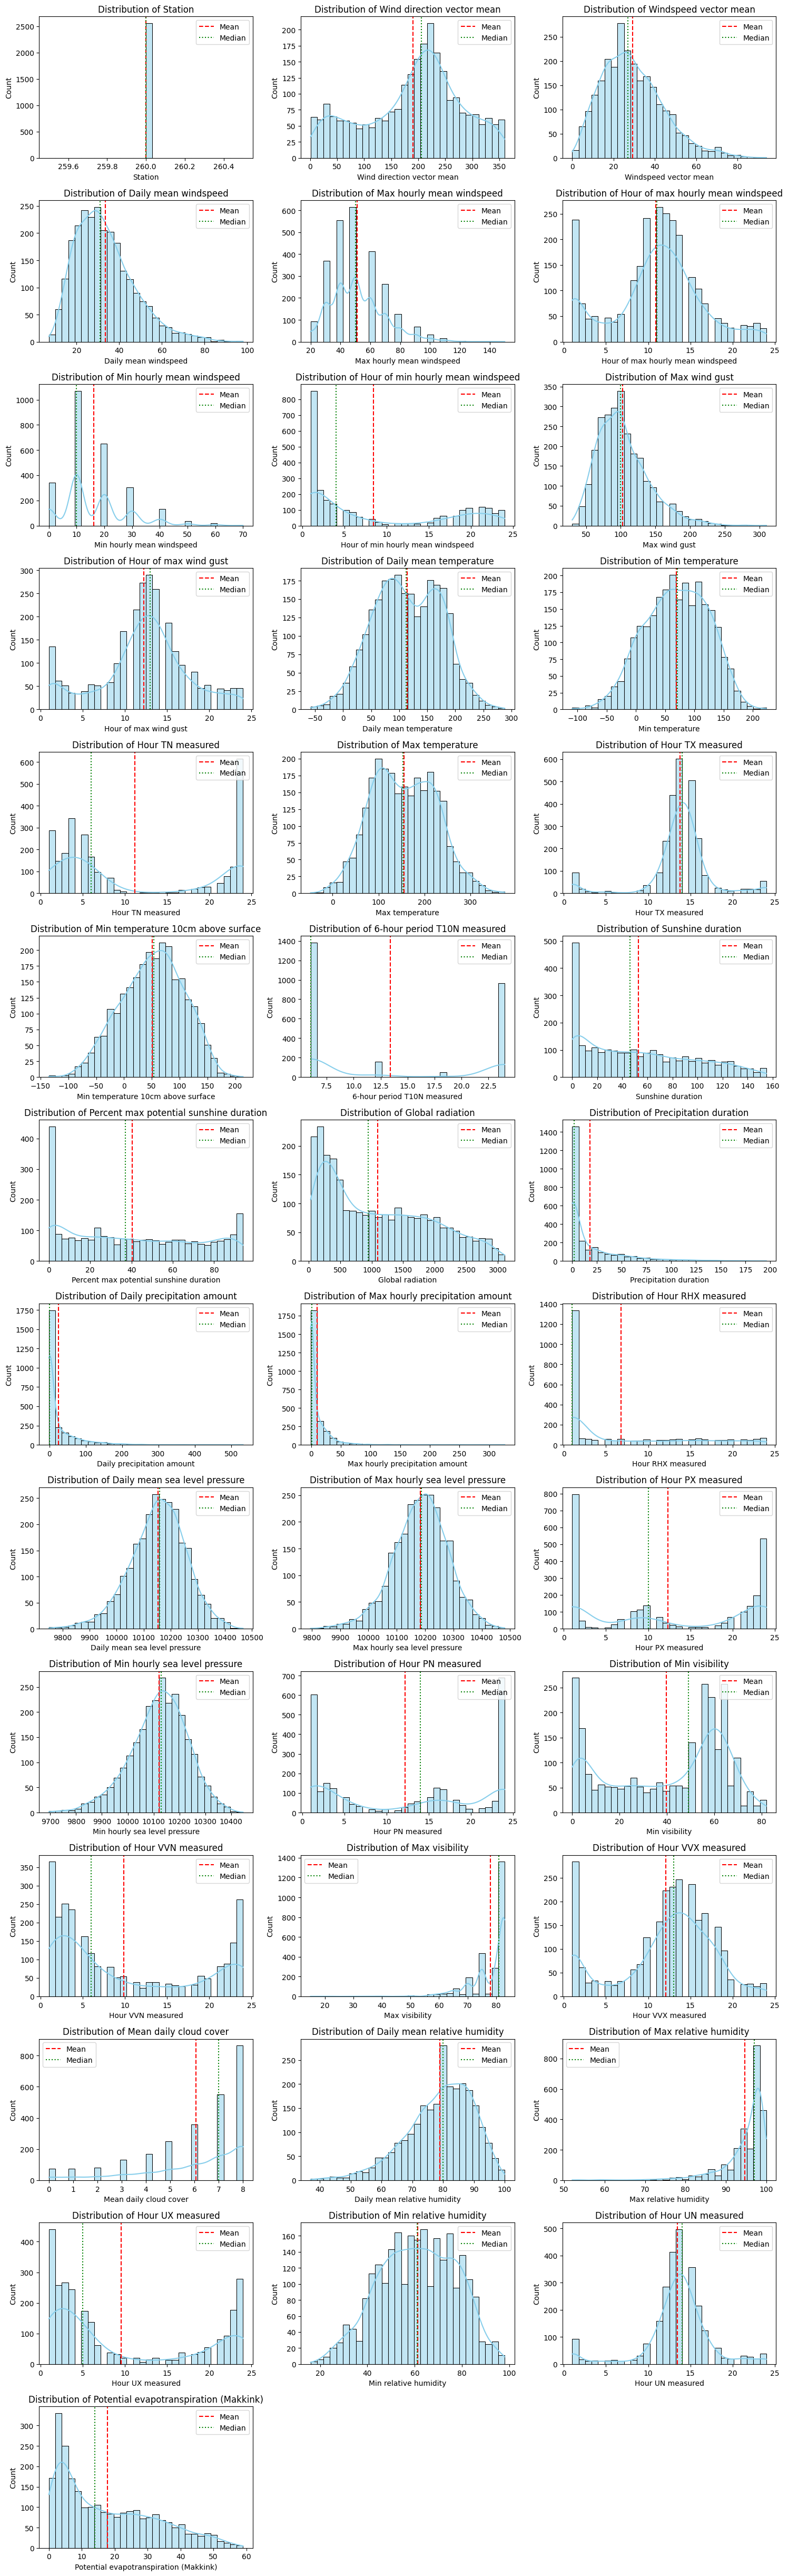

In [11]:
#histogram: for distribution and central tendency (mean, median)
n = len(num_cols)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = weather[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax, color="skyblue")
    ax.axvline(data.mean(), color="red", linestyle="--", label="Mean")
    ax.axvline(data.median(), color="green", linestyle=":", label="Median")
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")
    ax.legend()

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Bivariate

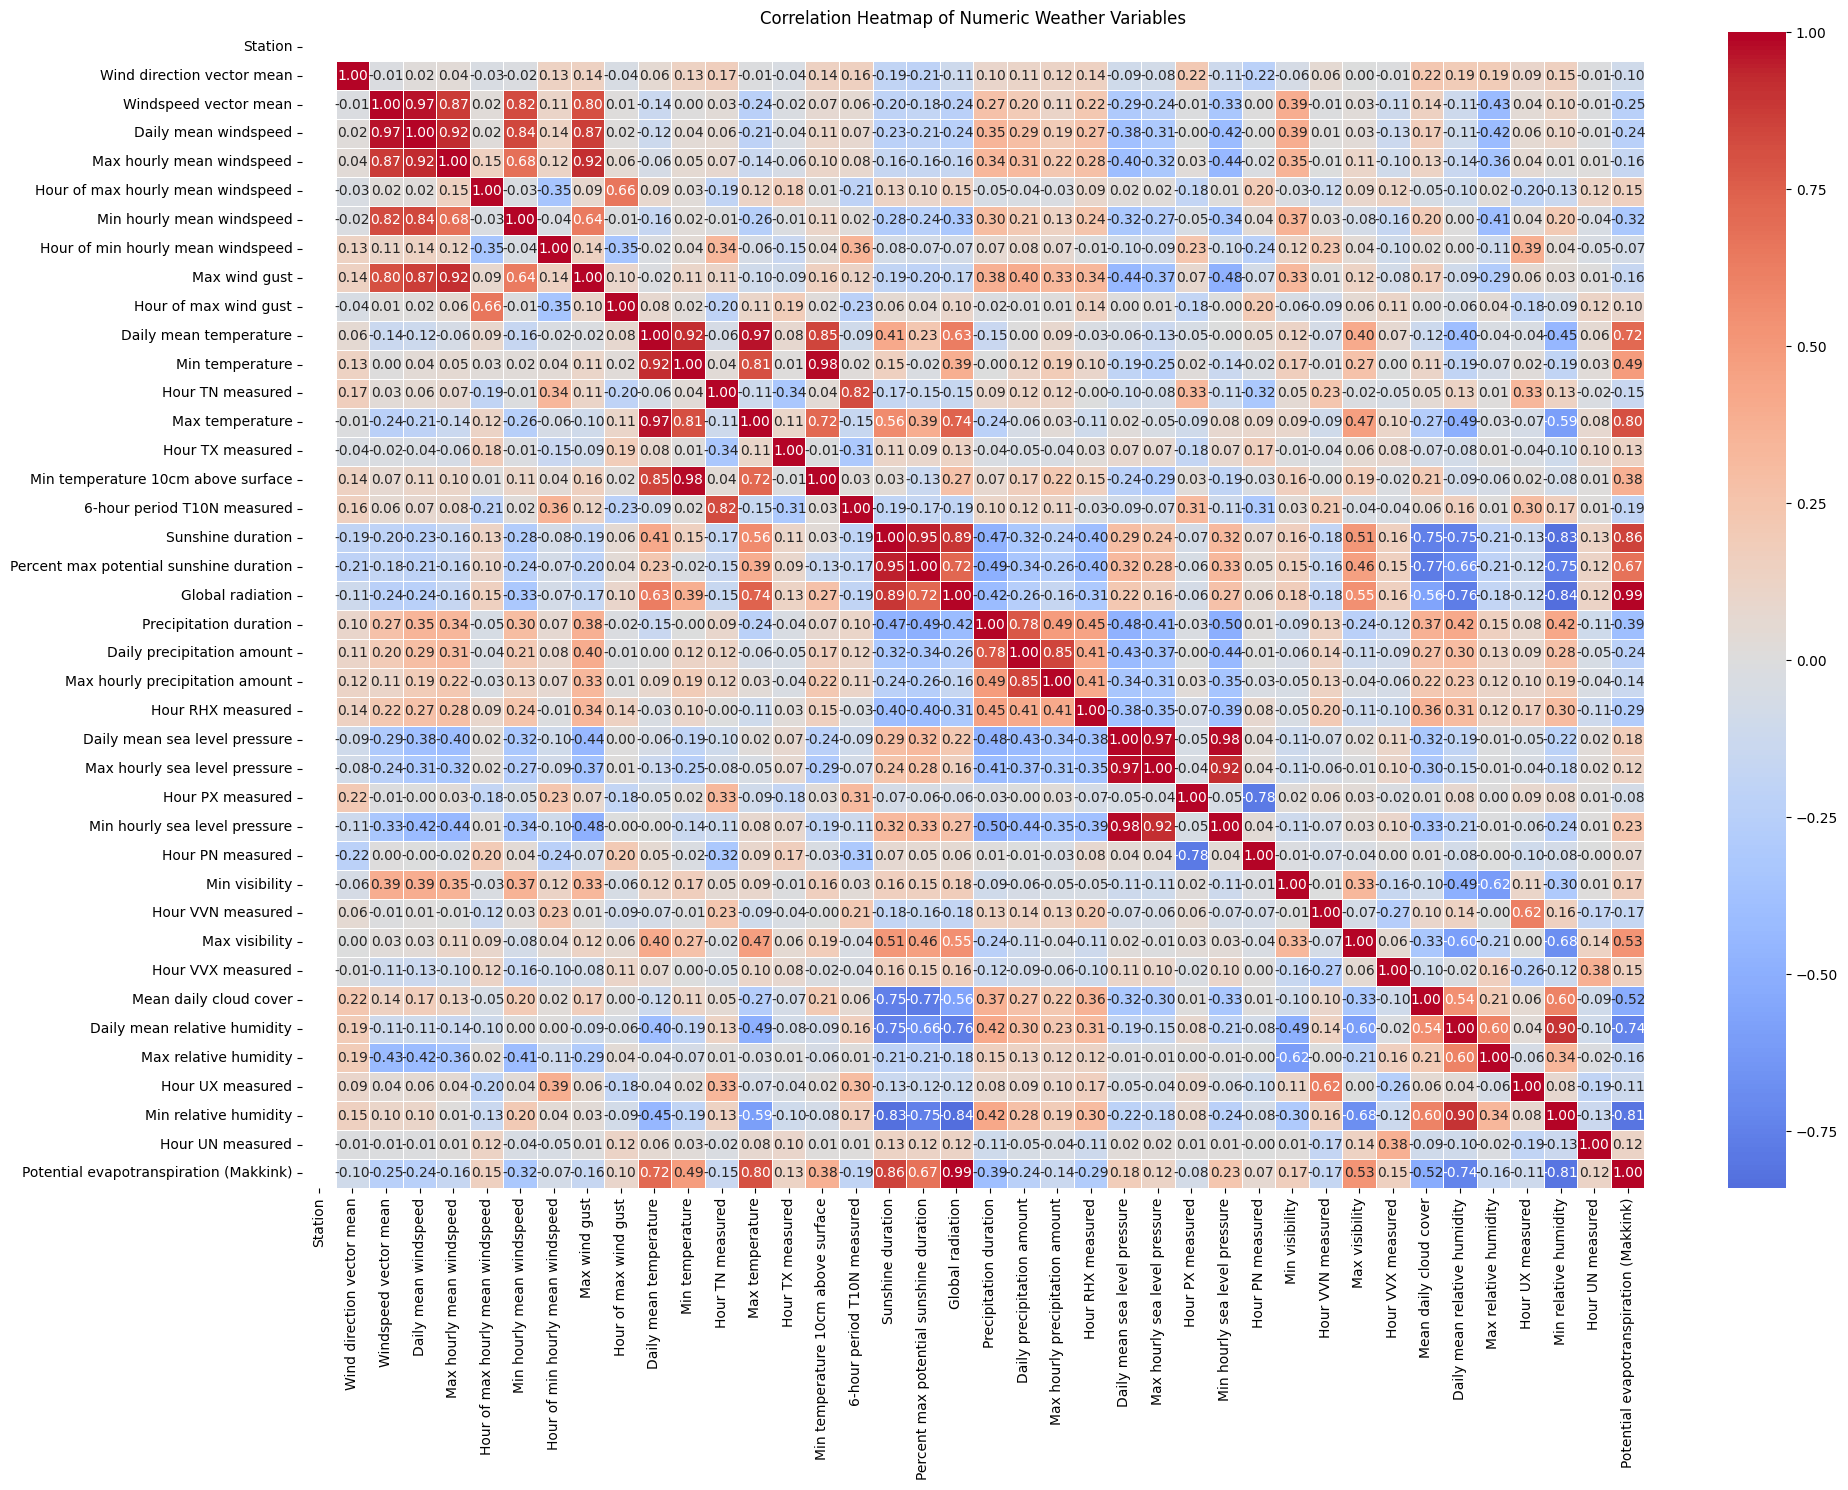

In [12]:
#heatmap: for correlation between numeric variables
corr = weather[num_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Weather Variables")
plt.tight_layout()
plt.show()

In [13]:
#check the top 10 most correlated pairs of numeric variables
corr_abs = weather[num_cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

top_pairs = upper.stack().sort_values(ascending=False).head(10)
print(top_pairs)

Global radiation               Potential evapotranspiration (Makkink)     0.986972
Min temperature                Min temperature 10cm above surface         0.980163
Daily mean sea level pressure  Min hourly sea level pressure              0.978490
                               Max hourly sea level pressure              0.974933
Daily mean temperature         Max temperature                            0.966511
Windspeed vector mean          Daily mean windspeed                       0.965609
Sunshine duration              Percent max potential sunshine duration    0.948298
Daily mean windspeed           Max hourly mean windspeed                  0.921756
Max hourly sea level pressure  Min hourly sea level pressure              0.919462
Daily mean temperature         Min temperature                            0.918034
dtype: float64


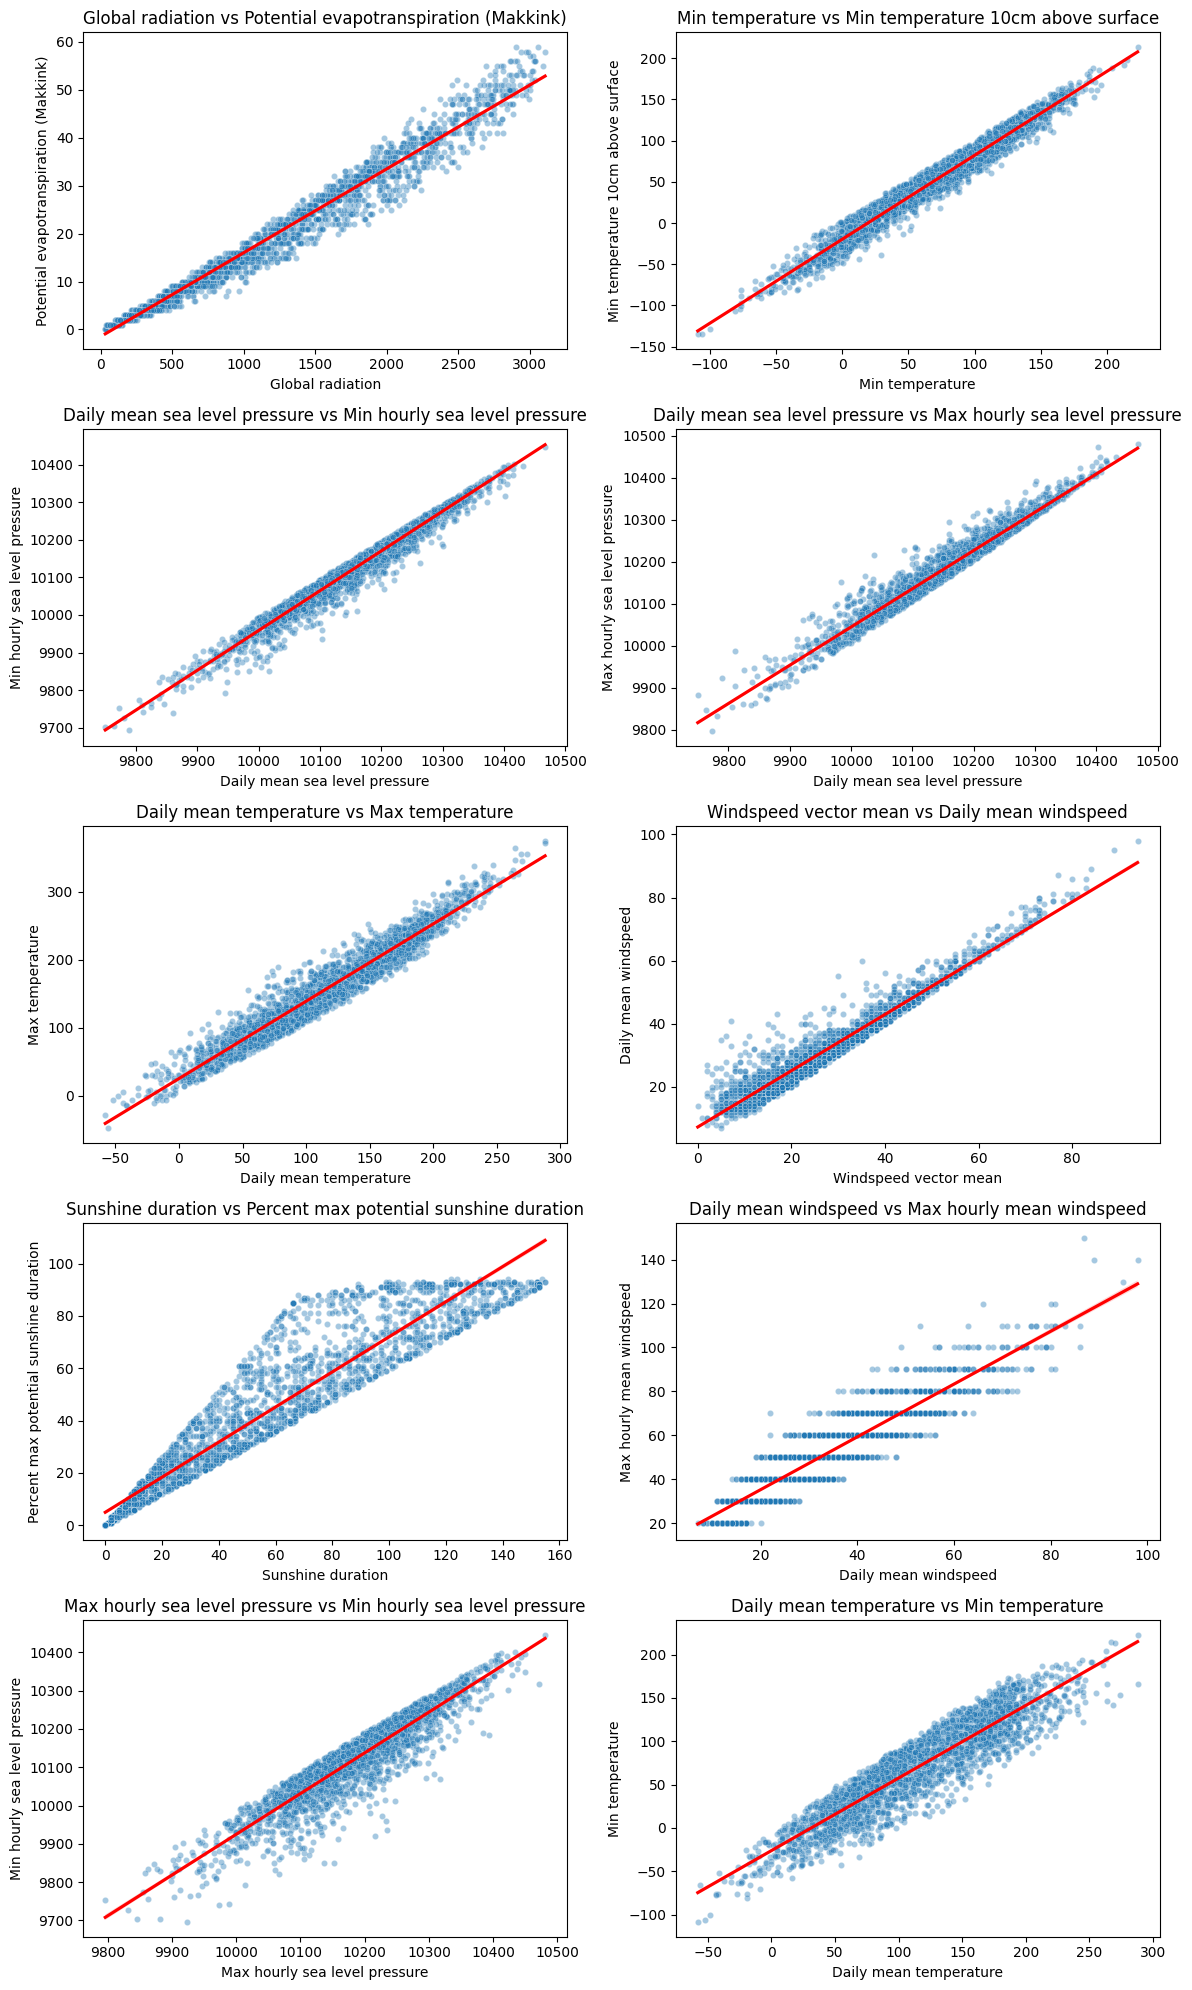

In [14]:
pairs = top_pairs.head(10).index.tolist()

n_pairs = len(pairs)
n_cols = 2
n_rows = math.ceil(n_pairs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=weather, x=x, y=y, alpha=0.4, s=20, ax=ax)
    sns.regplot(data=weather, x=x, y=y, scatter=False, color="red", ax=ax)
    ax.set_title(f"{x} vs {y}")

for ax in axes[n_pairs:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()